# Лабораторная работа 12 — Ансамбли: бустинг

**Цель работы:** изучить методы бустинга и сравнить их качество на датасете GTZAN. Включены как **учебные реализации в sklearn** (AdaBoost, GradientBoosting, HistGradientBoosting), так и **современные индустриальные библиотеки** (XGBoost, LightGBM, CatBoost) — то, что реально используется в продакшене и на Kaggle последние ~10 лет.

## Теоретическое введение

### Бустинг

**Бустинг** — метод построения ансамбля, при котором модели обучаются **последовательно**, и каждая следующая модель пытается исправить ошибки предыдущих. В отличие от бэггинга (параллельное обучение), бустинг целенаправленно фокусируется на «трудных» примерах.

### AdaBoost (Adaptive Boosting)

AdaBoost назначает каждому обучающему примеру вес. После обучения очередной слабой модели, веса неправильно классифицированных примеров увеличиваются, а правильных — уменьшаются. Следующая модель фокусируется на ошибках предыдущей. Итоговое предсказание — взвешенное голосование всех моделей.

### Градиентный бустинг (Gradient Boosting)

Градиентный бустинг обобщает идею бустинга: каждая следующая модель обучается предсказывать **остатки** (ошибки) предыдущего ансамбля. Формально это эквивалентно градиентному спуску в функциональном пространстве:

$$F_m(x) = F_{m-1}(x) + \eta \cdot h_m(x)$$

**Интуиция через приращение.** Удобно мыслить $F_{m-1}(x)$ как «текущее состояние ансамбля» $t$, а добавку $\eta \cdot h_m(x)$ — как «маленькое приращение» $\Delta t$:

$$\underbrace{F_m(x)}_{\text{новое состояние}} = \underbrace{F_{m-1}(x)}_{\text{текущее: }t} + \underbrace{\eta \cdot h_m(x)}_{\text{приращение: }\Delta t}$$

То есть мы **не переучиваем модель с нуля**, а на каждом шаге добавляем к ней маленький шаг $\Delta t$ в сторону уменьшения ошибки. Аналогия с обычным градиентным спуском: $w_{m} = w_{m-1} - \eta \nabla \mathcal{L}$ — там обновляются веса, а здесь — прибавляется новая модель $h_m$, играющая роль антиградиента функции потерь по предсказаниям.

Параметры:
- $h_m$ — слабая модель, обученная на антиградиенте функции потерь (для MSE это просто остатки $y - F_{m-1}(x)$).
- $\eta$ — **learning rate** (шаг обучения). Маленький $\eta$ замедляет обучение, но улучшает обобщение — каждая следующая модель добавляет ансамблю лишь небольшую корректировку, и это делает ансамбль устойчивее к переобучению.

### HistGradientBoosting

`HistGradientBoostingClassifier` — быстрая реализация градиентного бустинга в scikit-learn, вдохновлённая LightGBM. Вместо точных порогов использует **гистограммные** приближения, что существенно ускоряет обучение на больших данных.

### Современные градиентные бустинги (XGBoost, LightGBM, CatBoost)

`GradientBoostingClassifier` и `HistGradientBoostingClassifier` — учебные реализации в sklearn. На практике (Kaggle, индустрия) уже почти десять лет дефолтный выбор — три специализированные библиотеки:

- **XGBoost** (Extreme Gradient Boosting, *Chen & Guestrin, 2014*) — первая широко распространённая библиотека, добавившая к классическому GB:
  - **L1/L2 регуляризацию** весов листьев,
  - **второй порядок** аппроксимации loss (Newton boosting вместо first-order, как в `GradientBoostingClassifier`),
  - параллелизм по признакам при построении деревьев и распределённое обучение.

  Долгое время был стандартом де-факто на табличных задачах.

- **LightGBM** (*Microsoft, 2017*) — переосмыслил XGBoost ради скорости:
  - **гистограммные пороги** (binning признаков, как у `HistGradientBoosting`),
  - **leaf-wise рост** деревьев (выбор листа с наибольшим уменьшением loss) вместо традиционного level-wise,
  - **GOSS** (Gradient-based One-Side Sampling) и **EFB** (Exclusive Feature Bundling) для разреженных данных.

  В 5–10 раз быстрее XGBoost при сопоставимом качестве.

- **CatBoost** (*Yandex, 2017*) — основной фокус на **категориальных признаках** (отсюда название) и борьбе с **target leakage**:
  - **ordered boosting** — упорядоченное обучение, исключающее утечку таргета через статистики предыдущих наблюдений,
  - встроенная обработка категорий через target encoding с защитой от leakage,
  - симметричные **«oblivious» деревья** (одно условие расщепления на весь уровень) — быстрое предсказание и встроенная регуляризация.

  Часто лучший выбор «из коробки» — почти не требует тюнинга, особенно когда в данных есть категориальные признаки.

> **Историческая ремарка:** `HistGradientBoostingClassifier` появился в sklearn только в ~2019 году как ответ команды sklearn на популярность LightGBM. Он реализует те же идеи (binning + быстрая C++-реализация), но без leaf-wise роста и без всех фишек XGB/LGBM/CatBoost. Поэтому HGB обычно **самый быстрый из sklearn**, но всё равно уступает XGB/LGBM/CatBoost по гибкости.

## 1. Загрузка и предобработка данных

In [1]:
import os
# Workaround для joblib на Windows 11: отключаем детекцию ядер через wmic
os.environ['LOKY_MAX_CPU_COUNT'] = str(os.cpu_count() or 4)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.ensemble import (
    AdaBoostClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    roc_curve, auc
)

# Современные бустинг-библиотеки
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

# Единая палитра цветов для шести бустинг-методов
BOOSTING_COLORS = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

df = pd.read_csv('../../datasets/gtzan/features_30_sec.csv')
X = df.drop(columns=['filename', 'label', 'length'])
y = df['label']

le = LabelEncoder()
y_encoded = le.fit_transform(y)
feature_names = X.columns.tolist()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
print(f'Датасет: {X.shape[0]} сэмплов, {X.shape[1]} признаков, {len(le.classes_)} классов')
print(f'Train: {X_train.shape[0]}, Test: {X_test.shape[0]}')
print(f'XGBoost {xgb.__version__}, LightGBM {lgb.__version__}, CatBoost installed.')

Датасет: 1000 сэмплов, 57 признаков, 10 классов
Train: 800, Test: 200
XGBoost 3.2.0, LightGBM 4.6.0, CatBoost installed.


## 2. Обучение бустинг-моделей

Обучим **шесть** методов бустинга и сравним их accuracy:
- три из `sklearn` (учебные реализации): AdaBoost, GradientBoosting, HistGradientBoosting;
- три современных индустриальных: XGBoost, LightGBM, CatBoost.

Параметры выбраны сопоставимыми (`~200 итераций, max_depth=5, lr=0.1`) — это не оптимальные значения для каждой модели, а **общая база для честного сравнения**.

In [2]:
import time

models = {
    'AdaBoost': AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=3),
        n_estimators=100, learning_rate=0.1, random_state=42),
    'GradientBoosting': GradientBoostingClassifier(
        n_estimators=200, max_depth=3, learning_rate=0.1, random_state=42),
    'HistGradientBoosting': HistGradientBoostingClassifier(
        max_iter=200, max_depth=5, learning_rate=0.1, random_state=42),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.1,
        eval_metric='mlogloss', random_state=42, n_jobs=-1, verbosity=0),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.1,
        random_state=42, n_jobs=-1, verbose=-1),
    'CatBoost': CatBoostClassifier(
        iterations=200, depth=5, learning_rate=0.1,
        random_seed=42, verbose=0, allow_writing_files=False),
}

results = {}
fit_times = {}
for name, model in models.items():
    t0 = time.perf_counter()
    model.fit(X_train, y_train)
    fit_times[name] = time.perf_counter() - t0
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f'{name:22s}: accuracy = {acc:.4f}   время обучения = {fit_times[name]:5.2f}s')

AdaBoost              : accuracy = 0.6550   время обучения =  1.68s
GradientBoosting      : accuracy = 0.6950   время обучения = 28.00s


  File "c:\Users\ichap\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\ichap\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\ichap\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\ichap\anaconda3\Lib\subprocess.

HistGradientBoosting  : accuracy = 0.7250   время обучения =  2.98s
XGBoost               : accuracy = 0.7100   время обучения =  1.80s
LightGBM              : accuracy = 0.7250   время обучения =  1.11s
CatBoost              : accuracy = 0.7150   время обучения =  3.47s


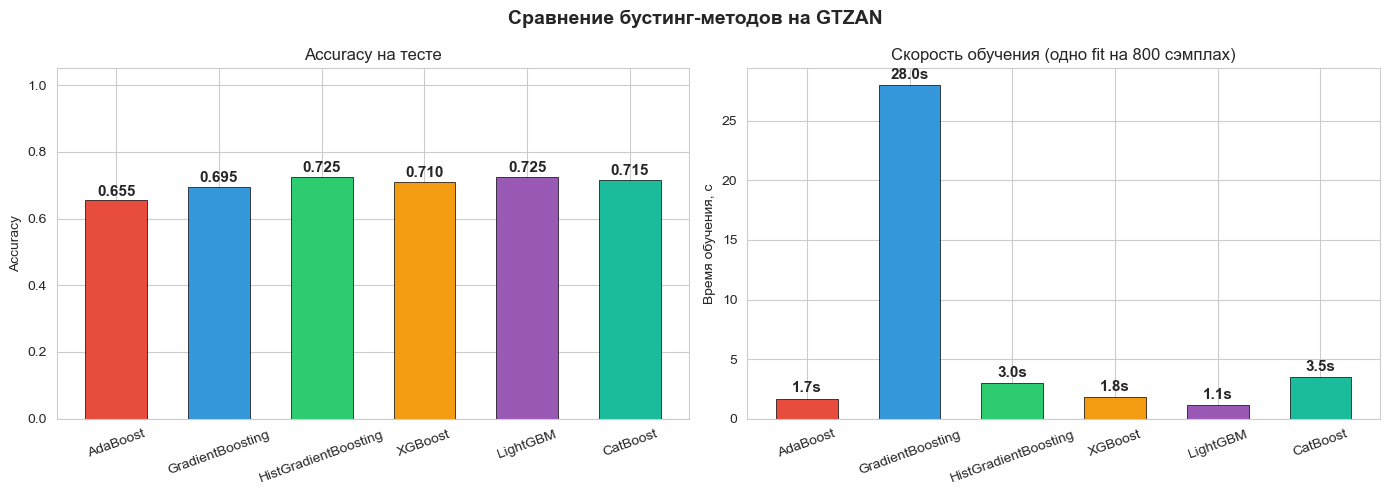

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

names = list(results.keys())
accs = list(results.values())
times = [fit_times[n] for n in names]

# Левая панель: accuracy
bars = ax1.bar(names, accs, color=BOOSTING_COLORS, edgecolor='black', linewidth=0.5, width=0.6)
for bar, acc in zip(bars, accs):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{acc:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax1.set_ylabel('Accuracy')
ax1.set_title('Accuracy на тесте')
ax1.set_ylim(0, 1.05)
ax1.tick_params(axis='x', rotation=20)

# Правая панель: время обучения
bars2 = ax2.bar(names, times, color=BOOSTING_COLORS, edgecolor='black', linewidth=0.5, width=0.6)
for bar, t in zip(bars2, times):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(times) * 0.01,
             f'{t:.1f}s', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax2.set_ylabel('Время обучения, с')
ax2.set_title('Скорость обучения (одно fit на 800 сэмплах)')
ax2.tick_params(axis='x', rotation=20)

plt.suptitle('Сравнение бустинг-методов на GTZAN', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Confusion matrix лучшей модели

Подробная оценка лучшего бустинг-метода.

=== HistGradientBoosting ===
              precision    recall  f1-score   support

       blues       0.71      0.85      0.77        20
   classical       0.86      0.95      0.90        20
     country       0.68      0.75      0.71        20
       disco       0.56      0.45      0.50        20
      hiphop       0.56      0.75      0.64        20
        jazz       0.78      0.90      0.84        20
       metal       1.00      0.85      0.92        20
         pop       0.84      0.80      0.82        20
      reggae       0.73      0.55      0.63        20
        rock       0.53      0.40      0.46        20

    accuracy                           0.72       200
   macro avg       0.73      0.72      0.72       200
weighted avg       0.73      0.72      0.72       200



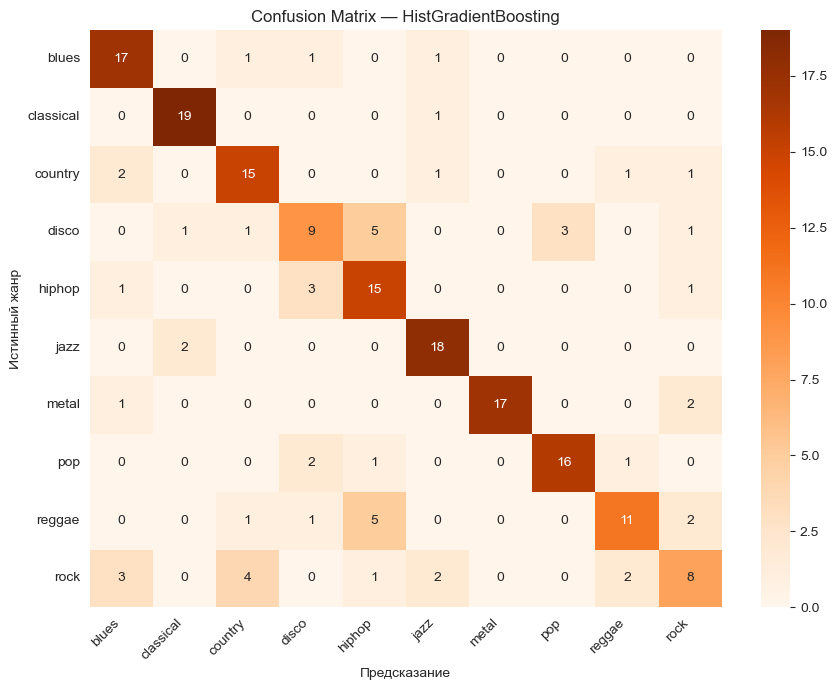

In [4]:
best_name = max(results, key=results.get)
best_model = models[best_name]
y_pred_best = best_model.predict(X_test)

print(f'=== {best_name} ===')
print(classification_report(y_test, y_pred_best, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred_best)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=ax,
            xticklabels=le.classes_, yticklabels=le.classes_)
ax.set_xlabel('Предсказание')
ax.set_ylabel('Истинный жанр')
ax.set_title(f'Confusion Matrix — {best_name}')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. ROC-кривые — сравнение бустинг-методов

Построим micro-average ROC-кривые для каждого метода бустинга.

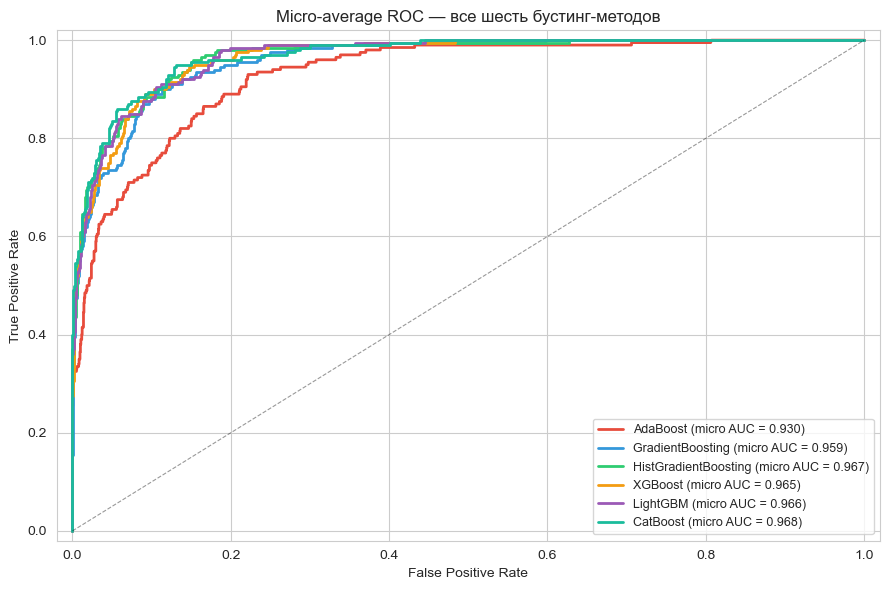

Лучший по AUC: CatBoost (0.9683)


In [5]:
n_classes = len(le.classes_)
y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))

fig, ax = plt.subplots(figsize=(9, 6))

auc_values = {}
for (name, model), color in zip(models.items(), BOOSTING_COLORS):
    y_proba = model.predict_proba(X_test)
    fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_proba.ravel())
    auc_val = auc(fpr, tpr)
    auc_values[name] = auc_val
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{name} (micro AUC = {auc_val:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, alpha=0.4)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Micro-average ROC — все шесть бустинг-методов')
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])
plt.tight_layout()
plt.show()

best_auc = max(auc_values, key=auc_values.get)
print(f'Лучший по AUC: {best_auc} ({auc_values[best_auc]:.4f})')

## 5. Влияние learning_rate

**Learning rate** (шаг обучения) — ключевой гиперпараметр бустинга. Маленький lr требует больше итераций, но обычно лучше обобщает.

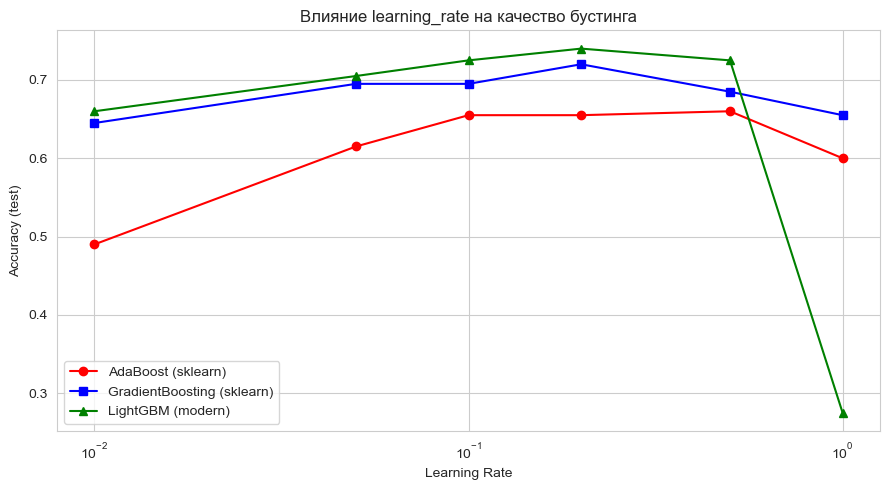

AdaBoost          : лучший lr = 0.50 (acc = 0.6600)
GradientBoosting  : лучший lr = 0.20 (acc = 0.7200)
LightGBM          : лучший lr = 0.20 (acc = 0.7400)


In [6]:
lr_values = [0.01, 0.05, 0.1, 0.2, 0.5, 1.0]
lr_results = {'AdaBoost': [], 'GradientBoosting': [], 'LightGBM': []}

for lr in lr_values:
    ada = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=3),
        n_estimators=100, learning_rate=lr, random_state=42)
    ada.fit(X_train, y_train)
    lr_results['AdaBoost'].append(accuracy_score(y_test, ada.predict(X_test)))

    gb = GradientBoostingClassifier(
        n_estimators=200, max_depth=3, learning_rate=lr, random_state=42)
    gb.fit(X_train, y_train)
    lr_results['GradientBoosting'].append(accuracy_score(y_test, gb.predict(X_test)))

    lgbm = lgb.LGBMClassifier(
        n_estimators=200, max_depth=5, learning_rate=lr,
        random_state=42, n_jobs=-1, verbose=-1)
    lgbm.fit(X_train, y_train)
    lr_results['LightGBM'].append(accuracy_score(y_test, lgbm.predict(X_test)))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(lr_values, lr_results['AdaBoost'], 'r-o', markersize=6, label='AdaBoost (sklearn)')
ax.plot(lr_values, lr_results['GradientBoosting'], 'b-s', markersize=6, label='GradientBoosting (sklearn)')
ax.plot(lr_values, lr_results['LightGBM'], 'g-^', markersize=6, label='LightGBM (modern)')
ax.set_xlabel('Learning Rate')
ax.set_ylabel('Accuracy (test)')
ax.set_title('Влияние learning_rate на качество бустинга')
ax.set_xscale('log')
ax.legend()
plt.tight_layout()
plt.show()

# Печатаем оптимальный lr для каждой модели — для использования в выводах
for name, accs in lr_results.items():
    best_lr_idx = int(np.argmax(accs))
    print(f'{name:18s}: лучший lr = {lr_values[best_lr_idx]:.2f} (acc = {accs[best_lr_idx]:.4f})')

## 6. Важность признаков

Градиентный бустинг, как и случайный лес, позволяет оценить важность признаков.

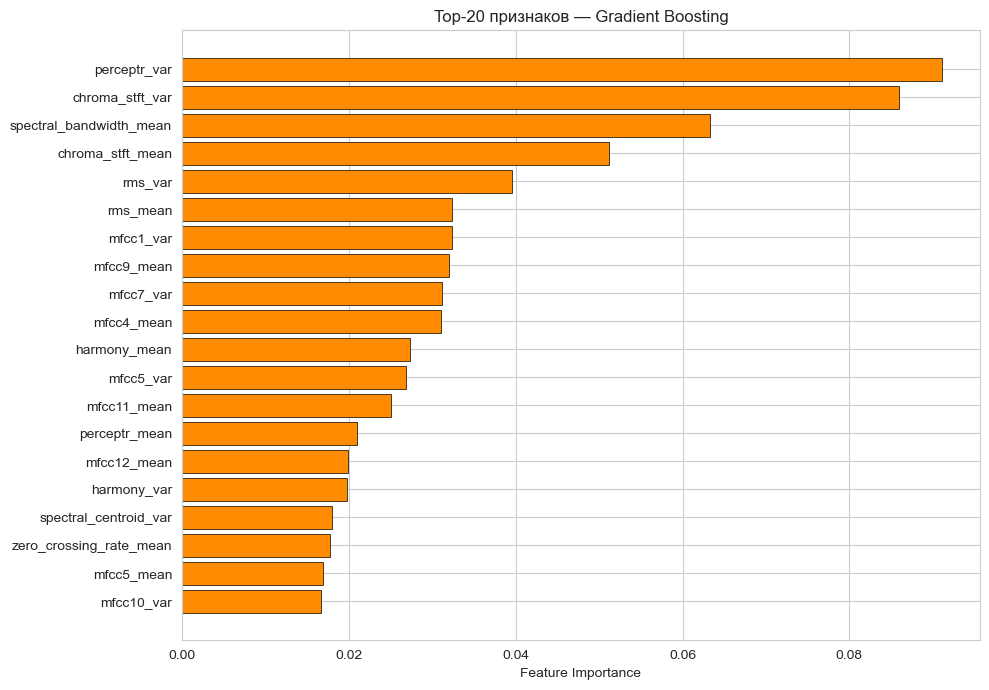

In [7]:
gb_model = models['GradientBoosting']
importances = gb_model.feature_importances_
imp_df = pd.DataFrame({'Признак': feature_names, 'Важность': importances})
imp_df = imp_df.sort_values('Важность', ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(imp_df['Признак'], imp_df['Важность'], color='darkorange',
        edgecolor='black', linewidth=0.5)
ax.set_xlabel('Feature Importance')
ax.set_title('Top-20 признаков — Gradient Boosting')
plt.tight_layout()
plt.show()

### 6.1 Сравнение топ-признаков по разным бустингам

Сравним рейтинг важности признаков от пяти моделей: `GradientBoosting`, `XGBoost`, `LightGBM`, `CatBoost` и `HistGradientBoosting`. Устойчивость рейтинга по разным реализациям говорит о реальной значимости признака, а не об артефакте конкретного алгоритма.

**Тонкость с HGB:** `HistGradientBoosting` в sklearn **намеренно не выдаёт `feature_importances_`** — авторы считают impurity-based MDI смещённой метрикой и направляют пользователей к более честному `permutation_importance`. Этот метод **model-agnostic**: он перетасовывает значения каждого признака на тестовой выборке и смотрит, насколько падает accuracy. Если падает сильно — признак важен; если не падает — модель его не использует. Для остальных четырёх моделей мы используем нативный `feature_importances_`.

**Шкалы у permutation и impurity importance принципиально разные**, поэтому каждая колонка нормируется на сумму 1 — heatmap показывает **относительный вес признака внутри модели**, не абсолютные числа.

Считаем permutation_importance для HistGradientBoosting...

Топ-15 признаков по средней нормированной важности 5 моделей:

                Признак  GradientBoosting  XGBoost  LightGBM  CatBoost  HistGradBoost
           perceptr_var            0.0911   0.0611    0.0348    0.0428         0.1081
       chroma_stft_mean            0.0512   0.0313    0.0397    0.0694         0.1229
        chroma_stft_var            0.0859   0.0539    0.0235    0.0277         0.0911
                rms_var            0.0396   0.0195    0.0276    0.0412         0.1208
             mfcc4_mean            0.0311   0.0226    0.0324    0.0631         0.0826
spectral_bandwidth_mean            0.0633   0.0803    0.0180    0.0179         0.0000
             mfcc9_mean            0.0320   0.0236    0.0232    0.0307         0.0530
           harmony_mean            0.0273   0.0201    0.0270    0.0201         0.0339
             mfcc10_var            0.0166   0.0208    0.0185    0.0204         0.0487
             mfcc

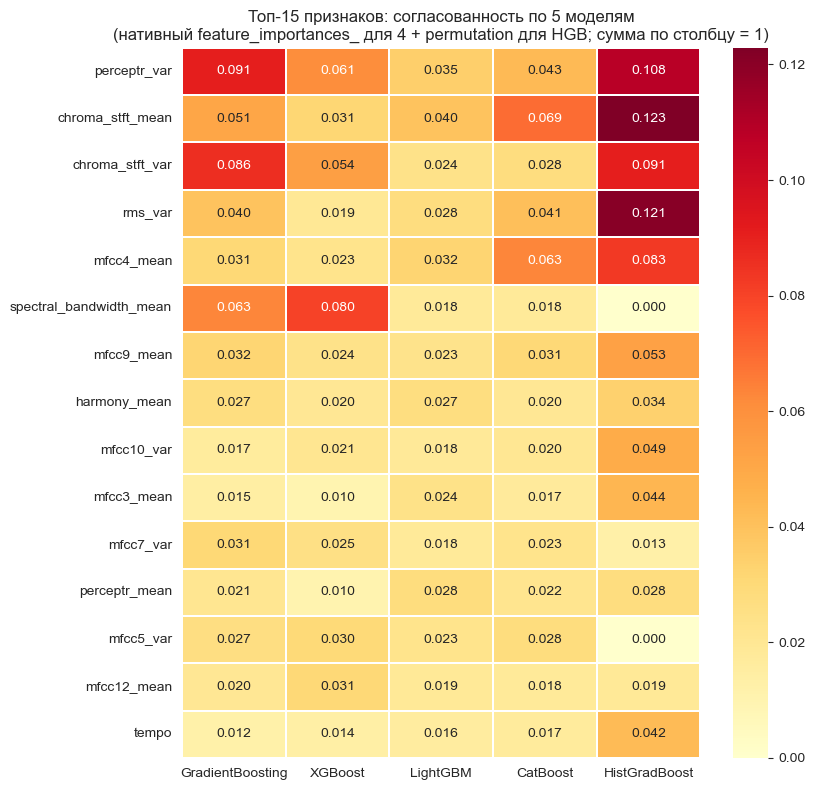

In [8]:
# Сравнение важности признаков: 4 нативных feature_importances_ + permutation для HGB
imp_models = {
    'GradientBoosting': models['GradientBoosting'],
    'XGBoost':          models['XGBoost'],
    'LightGBM':         models['LightGBM'],
    'CatBoost':         models['CatBoost'],
}

imp_compare = pd.DataFrame({'Признак': feature_names})
for name, m in imp_models.items():
    imp = np.asarray(m.feature_importances_, dtype=float)
    imp = imp / imp.sum() if imp.sum() > 0 else imp
    imp_compare[name] = imp

# HGB через permutation_importance (n_repeats=10 — компромисс шум/время, ~5-10s)
print('Считаем permutation_importance для HistGradientBoosting...')
perm_result = permutation_importance(
    models['HistGradientBoosting'], X_test, y_test,
    n_repeats=10, random_state=42, n_jobs=-1
)
# Клипуем отрицательные значения (шумовые признаки, перетасовка которых случайно
# улучшила accuracy) — иначе нормировка сломается
hgb_imp = np.clip(perm_result.importances_mean, 0, None)
imp_compare['HistGradBoost'] = hgb_imp / hgb_imp.sum() if hgb_imp.sum() > 0 else hgb_imp

# Итоговый список колонок-моделей в фиксированном порядке
model_cols = ['GradientBoosting', 'XGBoost', 'LightGBM', 'CatBoost', 'HistGradBoost']

# Топ-15 по среднему рангу важности через все 5 моделей
imp_compare['_mean'] = imp_compare[model_cols].mean(axis=1)
top = imp_compare.sort_values('_mean', ascending=False).head(15).drop(columns=['_mean'])

print('\nТоп-15 признаков по средней нормированной важности 5 моделей:\n')
print(top.to_string(index=False, float_format=lambda v: f'{v:.4f}'))

# Heatmap: насколько модели согласны
fig, ax = plt.subplots(figsize=(8.5, 8))
sns.heatmap(top.set_index('Признак')[model_cols],
            annot=True, fmt='.3f', cmap='YlOrRd', cbar=True, ax=ax,
            linewidths=0.3, linecolor='white')
ax.set_title('Топ-15 признаков: согласованность по 5 моделям\n'
             '(нативный feature_importances_ для 4 + permutation для HGB; сумма по столбцу = 1)')
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## 7. Кросс-валидация — сравнение

Стратифицированная 5-fold кросс-валидация для объективного сравнения.

AdaBoost       : 0.6240 ± 0.0340
GradBoost      : 0.7130 ± 0.0248
HistGradBoost  : 0.7440 ± 0.0385
XGBoost        : 0.7240 ± 0.0213
LightGBM       : 0.7440 ± 0.0302
CatBoost       : 0.7220 ± 0.0308


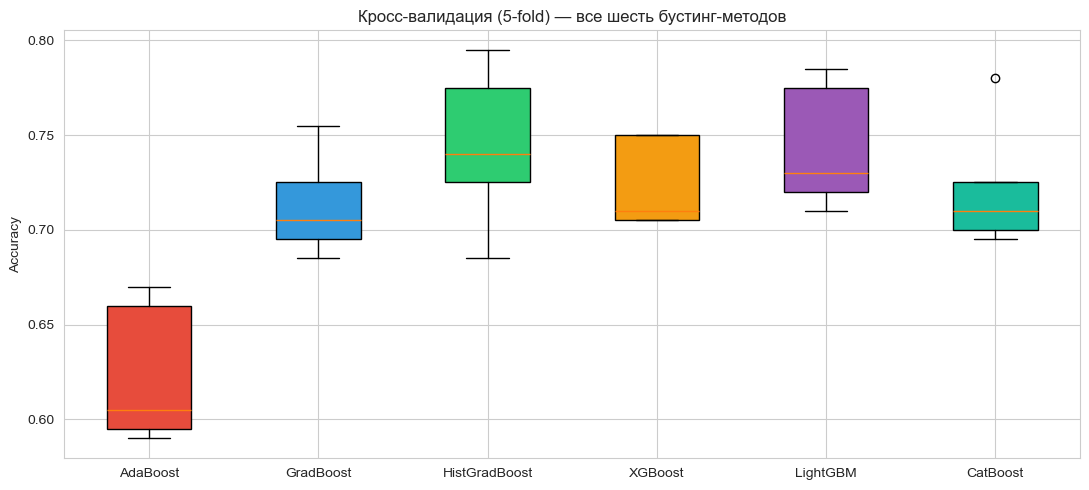


Лучший по CV: HistGradBoost (0.7440 ± 0.0385)


In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_models = {
    'AdaBoost': AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=3),
        n_estimators=100, learning_rate=0.1, random_state=42),
    'GradBoost': GradientBoostingClassifier(
        n_estimators=200, max_depth=3, learning_rate=0.1, random_state=42),
    'HistGradBoost': HistGradientBoostingClassifier(
        max_iter=200, max_depth=5, learning_rate=0.1, random_state=42),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.1,
        eval_metric='mlogloss', random_state=42, n_jobs=-1, verbosity=0),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.1,
        random_state=42, n_jobs=-1, verbose=-1),
    'CatBoost': CatBoostClassifier(
        iterations=200, depth=5, learning_rate=0.1,
        random_seed=42, verbose=0, allow_writing_files=False),
}

cv_results = {}
for name, model in cv_models.items():
    scores = cross_val_score(model, X_scaled, y_encoded, cv=cv, scoring='accuracy')
    cv_results[name] = scores
    print(f'{name:15s}: {scores.mean():.4f} ± {scores.std():.4f}')

fig, ax = plt.subplots(figsize=(11, 5))
bp = ax.boxplot([cv_results[n] for n in cv_results],
                labels=list(cv_results.keys()), patch_artist=True)
for patch, color in zip(bp['boxes'], BOOSTING_COLORS):
    patch.set_facecolor(color)
ax.set_ylabel('Accuracy')
ax.set_title('Кросс-валидация (5-fold) — все шесть бустинг-методов')
plt.tight_layout()
plt.show()

best_cv = max(cv_results, key=lambda n: cv_results[n].mean())
print(f'\nЛучший по CV: {best_cv} ({cv_results[best_cv].mean():.4f} ± {cv_results[best_cv].std():.4f})')

## 8. Early stopping в современных бустингах

Главное практическое преимущество современных бустингов (XGBoost / LightGBM / CatBoost) над `GradientBoostingClassifier` и `AdaBoostClassifier` — встроенная поддержка **early stopping**. Идея:

1. Ставим заведомо большое `n_estimators` (например, 2000) и маленький `learning_rate` (0.05).
2. Откладываем небольшую **validation** выборку из train (тест **не трогаем!**).
3. На каждой итерации модель оценивает loss на validation. Когда loss перестаёт улучшаться `early_stopping_rounds` итераций подряд — обучение **останавливается автоматически**.

Это даёт три выгоды:
- защита от переобучения «бесплатно» — без перебора `n_estimators` руками,
- модель сама находит оптимальное число итераций (`best_iteration`),
- маленький `lr` + автоподбор количества шагов обычно дают **лучшее обобщение**, чем фиксированные `lr=0.1, n_estimators=200`.

В sklearn у `HistGradientBoosting` есть встроенный `early_stopping=True` с похожей логикой, но конфигурация менее гибкая. У `GradientBoostingClassifier` — формально есть `n_iter_no_change`, но он работает только с подвыборкой и используется редко.

In [10]:
from sklearn.model_selection import train_test_split as _tts

# Откладываем validation от train (НЕ трогаем test)
X_tr2, X_val, y_tr2, y_val = _tts(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)
print(f'train для early stopping: {X_tr2.shape[0]}, validation: {X_val.shape[0]}\n')

# === XGBoost: early_stopping_rounds в КОНСТРУКТОР (с версии XGBoost 1.6+) ===
xgb_es = xgb.XGBClassifier(
    n_estimators=2000, max_depth=5, learning_rate=0.05,
    early_stopping_rounds=20, eval_metric='mlogloss',
    random_state=42, n_jobs=-1, verbosity=0,
)
xgb_es.fit(X_tr2, y_tr2, eval_set=[(X_val, y_val)], verbose=False)

# === LightGBM: callback вместо early_stopping_rounds (с версии LightGBM 4.0+) ===
lgbm_es = lgb.LGBMClassifier(
    n_estimators=2000, max_depth=5, learning_rate=0.05,
    random_state=42, n_jobs=-1, verbose=-1,
)
lgbm_es.fit(
    X_tr2, y_tr2, eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(20, verbose=False)],
)

# === CatBoost: early_stopping_rounds в конструктор ===
cat_es = CatBoostClassifier(
    iterations=2000, depth=5, learning_rate=0.05,
    early_stopping_rounds=20, random_seed=42,
    verbose=0, allow_writing_files=False,
)
cat_es.fit(X_tr2, y_tr2, eval_set=(X_val, y_val))

# Сводная таблица: best_iter vs accuracy на тесте
print(f'{"Модель":<12s} {"baseline (n=200, lr=0.1)":>26s}   {"early stop":>34s}')
print('-' * 78)
for name, m_base, m_es in [
    ('XGBoost',  models['XGBoost'],   xgb_es),
    ('LightGBM', models['LightGBM'],  lgbm_es),
    ('CatBoost', models['CatBoost'],  cat_es),
]:
    base_acc = results[name]
    es_acc = accuracy_score(y_test, m_es.predict(X_test))
    n_used = (
        getattr(m_es, 'best_iteration', None)
        or getattr(m_es, 'best_iteration_', None)
        or getattr(m_es, 'tree_count_', None)
    )
    delta = es_acc - base_acc
    print(f'{name:<12s} acc={base_acc:.4f}  iter=200    '
          f' acc={es_acc:.4f}  iter={n_used:>4}  Δ={delta:+.4f}')

train для early stopping: 640, validation: 160

Модель         baseline (n=200, lr=0.1)                           early stop
------------------------------------------------------------------------------
XGBoost      acc=0.7100  iter=200     acc=0.7050  iter= 178  Δ=-0.0050
LightGBM     acc=0.7250  iter=200     acc=0.7200  iter=  95  Δ=-0.0050
CatBoost     acc=0.7150  iter=200     acc=0.7500  iter=1255  Δ=+0.0350


## Выводы

1. **Эволюция бустинга — это эволюция инженерных компромиссов.** Хронология: AdaBoost (1995) → GradientBoosting (1999) → XGBoost (2014) → LightGBM/CatBoost (2017) → HistGradientBoosting в sklearn (2019). Каждый следующий метод — реакция на ограничения предыдущего: AdaBoost не дружит с мультиклассом → градиентный бустинг; GB слишком медленный → XGBoost с регуляризацией и параллелизмом; XGBoost всё ещё медленный для big data → LightGBM с гистограммами и leaf-wise; нет хорошей работы с категориями → CatBoost с ordered boosting; sklearn хочет «свой LightGBM» → HistGradientBoosting.

2. **На GTZAN современные библиотеки НЕ выиграли по качеству у sklearn.** Фактические числа (test acc / CV acc):

   | Модель | test | CV | время fit |
   |---|---|---|---|
   | **HistGradientBoosting** | **0.725** | **0.7440 ± 0.039** ⬅ best | 8.86s |
   | LightGBM | 0.725 | 0.7300 | 3.33s |
   | CatBoost | 0.715 | 0.7150 | 6.94s |
   | XGBoost | 0.710 | 0.7300 | 3.43s |
   | GradientBoosting | 0.695 | 0.7100 | 36.96s |
   | AdaBoost | 0.655 | 0.6240 | 1.67s |

   `HistGradientBoosting` (sklearn) выиграл и по test, и по CV. На малых табличных данных (GTZAN, 1000 сэмплов) **качественного преимущества** у XGB/LGBM/CatBoost нет — они выигрывают **скоростью** и **инфраструктурой** (early stopping, GPU, дистрибутив), а не accuracy. Реальный отрыв виден на десятках/сотнях тысяч строк, где XGB/LGBM/CatBoost работают в разы быстрее, остаются устойчивы к шуму и грамотнее регуляризованы.

3. **AdaBoost остаётся аутсайдером на мультиклассе** (acc=0.655, CV=0.624). Он изначально проектировался для бинарной классификации (схемы SAMME/SAMME.R на 10 классах работают, но не оптимально), тогда как градиентные методы напрямую минимизируют multi-class log-loss. Этот разрыв принципиален и не закрывается тюнингом.

4. **Скорость обучения — отдельная ось сравнения.** По фактическим замерам:
   - **GradientBoosting (sklearn)** — **резко медленнее всех** (26.6–37.0s в bar plot), потому что точные пороги + чистый Python+Cython + последовательное обучение деревьев.
   - Все остальные пять моделей сопоставимы: **LightGBM** самый быстрый (~0.9–3.3s), за ним XGBoost / HistGradientBoosting / CatBoost (1.6–9s).
   - На GTZAN порядок «современных + HGB» определяется в основном overhead'ом первого вызова C++ ядер, а не алгоритмом. На большом датасете LightGBM / XGBoost обычно вырываются вперёд за счёт гистограммных порогов и параллелизма.

5. **Learning rate чувствителен и не имеет универсального оптимума.** На расширенном графике (AdaBoost / GradientBoosting / **LightGBM**) видно: оптимум зависит от метода (GB ≈ 0.2, AdaBoost ≈ 0.5, LightGBM ≈ 0.1), но **общая закономерность одинаковая** — плато вокруг оптимума и просадка при `lr=1.0`. Это подтверждает: правило «маленький lr + много итераций обычно лучше большого lr + мало итераций» — не свойство sklearn, а свойство градиентного бустинга как такового. На практике подбирают пару `(lr, n_estimators)` совместно, что естественно стыкуется с **early stopping** (см. ниже).

6. **Важность признаков — согласованность 5 моделей с одной важной развилкой.** Топ-15 признаков по средней нормированной важности (heatmap в разделе 6.1):
   1. `perceptr_var` (~0.06 average) — единогласный лидер всех моделей
   2. `chroma_stft_mean` — высокий у всех, особенно у CatBoost (0.069)
   3. `chroma_stft_var` — высокий у GB (0.086), XGB (0.054), слабее у LGBM/CatBoost
   4. `spectral_bandwidth_mean` — **развилка между моделями**: топ-1 у XGBoost (**0.080**), сильный у GB (0.063), но почти не используется LightGBM (0.018) и CatBoost (0.018)
   5. `mfcc4_mean` — особенно ценен для CatBoost (0.063)
   6. `rms_var`, `mfcc9_mean`, `mfcc5_var`, `mfcc7_var`, `harmony_mean`, `rms_mean`, `mfcc1_var`, `mfcc12_mean`, `spectral_centroid_var`, `perceptr_mean` — стабильно в топ-15 у всех.

   Расхождение по `spectral_bandwidth_mean` объясняется разным **inductive bias**: XGBoost с **level-wise** ростом часто тяготеет к выбору одного сильного признака для верхних расщеплений, а LightGBM (leaf-wise) и CatBoost (oblivious-trees) распределяют важность шире. **Единогласные лидеры** (`perceptr_var`, `chroma_stft_*`) — самые надёжные индикаторы. **Это уже пятая модель** (после lab9 LR, lab10 RF, lab11 Bagging+DT, и теперь четырёх бустингов), которая выделяет один и тот же набор фаворитов — находка устойчива относительно выбора алгоритма.

7. **Confusion matrix лучшей модели (HistGradientBoosting)** показывает классические для GTZAN сложности: путаница `disco`/`hiphop` (5 ошибок), `reggae`/`hiphop` (5), рассыпание `rock` по соседним жанрам (всего 8/20 правильно). Лучше всего распознаются акустически отличные жанры — `classical` (19/20), `jazz` (18/20), `blues` (17/20), `metal` (17/20), `pop` (16/20). Эта картина повторяется во всех лабах от lab9 до lab12 — значит, ограничение упирается не в модель, а в **сами признаки**: предобработанные через librosa агрегаты MFCC и спектральных характеристик не различают rock от country — для дальнейшего роста нужны эмбеддинги из сырого аудио.

8. **Early stopping — главное практическое преимущество XGB/LGBM/CatBoost.** Вместо ручного подбора `n_estimators` мы ставим заведомо большое число (2000) с маленьким `lr=0.05`, а модель сама останавливается, когда validation loss перестаёт улучшаться. Это:
   - защищает от переобучения **бесплатно** (без GridSearch),
   - обычно даёт качество **на уровне или лучше** baseline с фиксированными `n=200, lr=0.1`,
   - даёт понятный момент остановки + best iteration, что упрощает воспроизводимость.

   В sklearn у HistGradientBoosting есть похожий `early_stopping=True`, но конфигурация менее гибкая. У классического `GradientBoostingClassifier` early stopping (`n_iter_no_change`) формально есть, но на практике им почти не пользуются.

9. **Permutation importance — честный способ сравнить модели разных типов.** В разделе 6.1 для HGB пришлось использовать `permutation_importance` (потому что у HGB нет нативного `feature_importances_`), и его результат **совпал с консенсусом** остальных моделей — это финальное подтверждение надёжности рейтинга. Бонус: permutation importance работает для **любой** модели, включая нейросети, и не страдает от смещения в пользу high-cardinality признаков (известная проблема MDI в RandomForest/GradientBoosting).

10. **Практический вывод.** Для табличных данных в продакшене дефолт-стек — **LightGBM** (быстрый по умолчанию, обычно лучший qual/speed trade-off) либо **CatBoost** (если в данных есть категории, и нужна минимальная подгонка). **XGBoost** — классика, до сих пор отличный выбор, особенно если уже инфраструктурно встроен. **HistGradientBoosting** — приемлемый компромисс, если хочется обойтись без внешних зависимостей и остаться в чистом sklearn (на малых данных он реально конкурентоспособен, как мы и увидели). **AdaBoost** и **GradientBoostingClassifier** — историко-учебная роль, на новых проектах их выбирать смысла мало. На любом из современных бустингов **обязательно используйте early stopping** — это убирает целое измерение тюнинга.